## D'abords: trouvant k on utilisant la fonction G-means:  
- LINK TO THE ARTICLE I GOT THE IDEA FROM: https://proceedings.neurips.cc/paper/2003/hash/234833147b97bb6aed53a8f4f1c7a7d8-Abstract.html  
- Ce code utilise la distribution gaussienne pour trouver le nombre k de clusters. Ce n'est pas une solution très bonne car les données ne sont pas toujours parfaitement distribuées. POUR L'AMELIORER, j'AI ajouter des contraintes à ma distribution gaussienne pour arrêter la séparation des clusters si la condition est vérifiée.   
#### - THE FIRST CONTRAINT **(SOLUTION 1)**   
Nous calculons le score de silhouette et arrêtons de séparer si il diminue.   
#### - THE SECOND CONTRAINT **(SOLUTION 2)**  
Nous calculons l'indice de Davies-Bouldin (DBI) :  
- - Un DBI plus bas → de meilleurs clusters  
- - Si la nouvelle séparation augmente le DBI, on arrête de séparer.  

### SOLUTION 1:  
- Dans ce premier code, j'ai ajouté la contrainte de comparer le score de silhouette et d'arrêter si celui-ci diminue.  
- De plus, la distribution est très sensible aux données avec de nombreuses dimensions, c'est pourquoi, avant d'appliquer le G-Means sur mes données, j'ai appliqué une PCA pour réduire la dimension.  

In [11]:
# THE CONTRAINT :
# TO STOP SPLITTING IF THE NEXT SPLIT WILL HAVE A BIGGER silhouette_score
#-----------------------------------------------------------
# I TRIED IT AT THE AND ON DIFFRENT PREDEFINED DATASETS THAT WE ALREADY KNOW 
# HOW MANY K THEY NEED TO MEASURE THEIR PERFORMANCE

import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import anderson
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits, load_wine, load_breast_cancer, make_blobs, make_moons, make_circles, fetch_olivetti_faces, fetch_lfw_people
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def g_means(X, alpha=0.01, max_k=None, random_state=42):
    # Step 0: Preprocessing
    # The VarianceThreshold removes features from the data that have low variance 
    # (i.e., features that do not change much across samples and are therefore not 
    #  informative). Any feature with a variance less than 0.1 is discarded.
    #X = VarianceThreshold(threshold=0.1).fit_transform(X)  # Remove low-variance features

    # PCA is used to reduce the dimensionality of the data while preserving as much 
    # variance as possible. The number of components is determined by the smaller 
    # of 10 or 90% of the original features, with a minimum of 2 components.
    n_components = max(2, min(10, int(0.9 * X.shape[1])))  # Keep 2-10 dimensions
    X_reduced = PCA(n_components=n_components).fit_transform(X)
    
    # Step 1: Initialize
    if max_k is None:
        max_k = min(15, int(0.1 * len(X)))  # Dynamic cap
    
    #this basicaly calculates la moyenne of each column in the reduced
    #  dataset then returns it as an array
    centers = [np.mean(X_reduced, axis=0)]#axis=0 : the mean is calculated column-wise
    # print(centers)
    

    # The silhouette score is a metric that measures how well-separated the clusters 
    # are. It is tracked to ensure that the algorithm stops splitting if the clusters
    # become worse.
    prev_silhouette = None 
    
    # Step 2: Iterative splitting
    # This is the core of the algorithm. The algorithm iteratively splits the 
    # dataset into clusters until the maximum number of clusters (max_k) is 
    # reached or until further splitting is deemed unnecessary.
    while len(centers) < max_k:
        # ------n_clusters=len(centers):This specifies how many clusters the KMeans algorithm will create
        # initialy its =1
        # ------init=np.array(centers):The centers list contains the centroids of each cluster. 
        # Initially, theres only one centroid, which is the mean of the entire dataset.
        # ------n_init=1 parameter controls how many times the KMeans algorithm will run
        # but since im providing a specific initialization with init=, no need to initialize randomly multiple times. 
        # Therefore, n_init is set to 1
        kmeans = KMeans(n_clusters=len(centers), init=np.array(centers), n_init=1, random_state=random_state)
        # fit_predict is a method that performs two operations in one:
        # 1. fit: It trains the KMeans algorithm on the input data (X_reduced). This means it will assign clusters
        # to the data points by minimizing the distance to the cluster centers.
        # 2. predict: After fitting the model, this method assigns each data point in X_reduced to one of the 
        # clusters by predicting which cluster it belongs to.
        # The result of fit_predict is a list of cluster labels (one label for each data point),
        # where each label corresponds to the index of the cluster the data point belongs to, 
        # FOR EG: IN THE BEGINING WHEN K=1 LABELS IS A LIST OF 0 AS THEY ALL BELONG TO THE SAME CLASS INITIALLY
        labels = kmeans.fit_predict(X_reduced)
        # print(labels)
        # This line updates the list of cluster centers, initially (when k=1) its the same as the first 
        # centes: the mean of the whole data set, then when k increases, each cluster has its own centers array
        centers = kmeans.cluster_centers_
        # print(centers)
        
        # Compute silhouette score only if k > 1
        if len(centers) > 1:
            current_silhouette = silhouette_score(X_reduced, labels)
            
            # The silhouette score is computed after each iteration. 
            # If the silhouette score decreases (indicating that the new 
            # clusters are worse than the previous ones), the algorithm stops splitting.
            if prev_silhouette is not None and current_silhouette < prev_silhouette:
                break  # Stop splitting if clusters are getting worse
            prev_silhouette = current_silhouette  # Update best silhouette score
        
        new_centers = []
        changed = False
        # For each cluster, the algorithm attempts to split the cluster into 
        # two if it detects that the data within the cluster is not normally distributed.
        for j in range(len(centers)):
            #For each cluster (j), the data points belonging to that cluster are selected using the labels array.
            cluster_data = X_reduced[labels == j]
            #This variable defines the minimum size a cluster must have to be considered for splitting.
            min_cluster_size = max(10, int(0.02 * len(X)))
            #Skip small clusters
            if len(cluster_data) < min_cluster_size:
                new_centers.append(centers[j])
                continue
                
            # Projection and Gaussian test
            # For each cluster, the data points are centered around the cluster center,
            # and a covariance matrix is computed. The eigenvectors and eigenvalues 
            # of the covariance matrix are computed to identify the main direction 
            # of the cluster (the direction of maximum variance). The data points 
            # are then projected onto this direction.
            centered = cluster_data - centers[j]#This step is done to align the cluster's mean at the origin.
            # print('centered')
            # print(centered)
            cov = np.cov(centered.T)#The covariance matrix is computed for the centered data to understand how the data is spread along different dimensions.
            eigvals, eigvecs = np.linalg.eigh(cov)
            direction = eigvecs[:, np.argmax(eigvals)]

            # The centered data is projected onto the principal direction (the eigenvector with 
            # the largest eigenvalue). This essentially "flattens" the data into a single dimension 
            # along the direction of maximum variance
            projected = np.dot(centered, direction)
            
            # The Anderson-Darling test is used to check if the projected data follows a 
            # normal distribution. If the statistic (ad_stat) is greater than the 
            # critical value, this suggests that the cluster is not normally 
            # distributed, and splitting may be needed.
            standardized = (projected - np.mean(projected)) / np.std(projected)
            ad_stat = anderson(standardized).statistic
            critical = anderson(standardized).critical_values[2] * (1 + np.log(len(cluster_data)) / 10)
            
            # If the Anderson-Darling statistic exceeds the critical value, the cluster 
            # is split into two by creating two new centers that are offset along the 
            # principal direction of the cluster.
            if ad_stat > critical:
                offset = 0.3 * np.std(projected) * direction  # Smaller split
                new_centers.extend([centers[j] + offset, centers[j] - offset])
                changed = True
            else:
                new_centers.append(centers[j])



            
        # If no new centers were added after trying to split the clusters, the algorithm stops.
        if not changed:
            break
        centers = new_centers
    
    # Final result
    return len(centers)


# Predefined datasets and their expected cluster counts
datasets = {
    "Iris": (load_iris().data, 3),
    "Digits": (load_digits().data, 10),
    "Wine": (load_wine().data, 3),
    "Breast Cancer": (load_breast_cancer().data, 2),
    "Blobs": (make_blobs(n_samples=300, centers=4, random_state=42)[0], 4),
    "Moons": (make_moons(n_samples=300, noise=0.05, random_state=42)[0], 2),
    "Circles": (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2),
}

true_k_values = []
predicted_k_values = []
dataset_names = []

# Run G-Means on each dataset
for name, (X, true_k) in datasets.items():
    predicted_k = g_means(X, alpha=0.01)
    print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}")
    dataset_names.append(name)
    true_k_values.append(true_k)
    predicted_k_values.append(predicted_k)


Dataset: Iris, True k: 3, Predicted k: 3
Dataset: Digits, True k: 10, Predicted k: 15
Dataset: Wine, True k: 3, Predicted k: 2
Dataset: Breast Cancer, True k: 2, Predicted k: 4
Dataset: Blobs, True k: 4, Predicted k: 4
Dataset: Moons, True k: 2, Predicted k: 4
Dataset: Circles, True k: 2, Predicted k: 2


#### FURTHER EXPLANATION OF THE G MEANS ALGORITHM:  

            ok so basicaly all these calculations (THIS LAST LOOP) to make the data only one dimesion then organise 
            these numbers then see if when plotting them they will give a bell shaped graph (gaussian)!!?
        
            so we performes acp twice:
            1st PCA (At the Beginning) – Dimensionality Reduction for Stability
            Why do this?
            The original data might have too many dimensions, making clustering unstable and inefficient.
            Many clustering algorithms (including K-Means) struggle in high-dimensional spaces because of the curse of dimensionality.
            Reducing to 2-10 dimensions helps remove noise and make clustering more effective.
            This step ensures that the dataset has a more manageable number of features while keeping most of the important information.
        
            2nd PCA (During Cluster Splitting) – Finding the Principal Direction
            Why do this?
            Once we have a single cluster, we want to check if its data points follow a normal (Gaussian) distribution.
            Instead of looking at the full multi-dimensional space, we find the main direction where the data varies the most (the principal axis).
            Projecting the cluster’s data onto this one-dimensional axis lets us test if the data forms a bell-shaped distribution (i.e., is normally distributed).
            This helps decide whether to split the cluster or keep it as it is.


            WHAT DOES THE GAUSSIAN DISTRIBUTION LOGICALLY/ STATISTCALLY MEAN?? WHY IS IT A GOOD WAY TO SEE IF THE DATA IS RELATED??
            --- 1--- What is a Gaussian Distribution?
            A Gaussian distribution is a probability distribution that has a bell-shaped curve when plotted. It is defined by two main parameters:
            Mean (μ): The center of the distribution.
            Standard Deviation (σ): How spread out the data is around the mean.
            F(X)=   [1/(SQRT(2*P*(σ)^2))]* EXP^(-([X-μ]^2)/(2* (σ)^2))
            This equation describes how likely different values of x are, given a mean μ and standard deviation σ.

            --- 2--- Why is Gaussian a Good Way to Check If Data is Related?
            The Gaussian distribution naturally appears in real-world data because of the Central Limit Theorem (CLT):
            Many real-world measurements (e.g., height, weight, IQ scores) tend to follow a Gaussian distribution.
            When many small random factors influence a system, their sum tends to be normally distributed.
            In Clustering, this means:
            If data points come from the same underlying process, they often form a Gaussian cluster.
            If they don’t, it suggests that the cluster is actually made of multiple different groups.
        
            --- 3 --- Why Use the Anderson-Darling Test for Normality?
            The Anderson-Darling test helps us formally check whether a dataset follows a Gaussian (normal) distribution.
            If the test confirms normality → The cluster is correct, don’t split.
            If the test rejects normality → The cluster is likely made of multiple sub-clusters, split it.
            This is a statistical way to decide if the data inside a cluster belongs together!

            

#### Measure the performance of my algorithm:

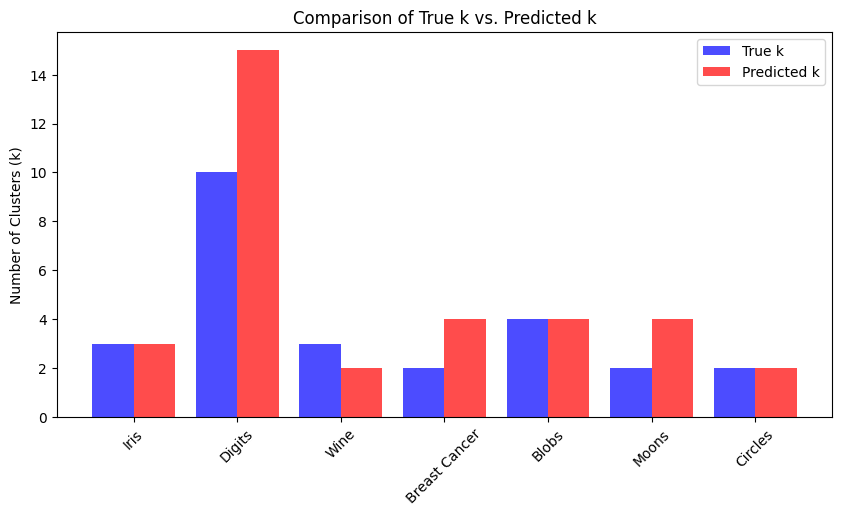

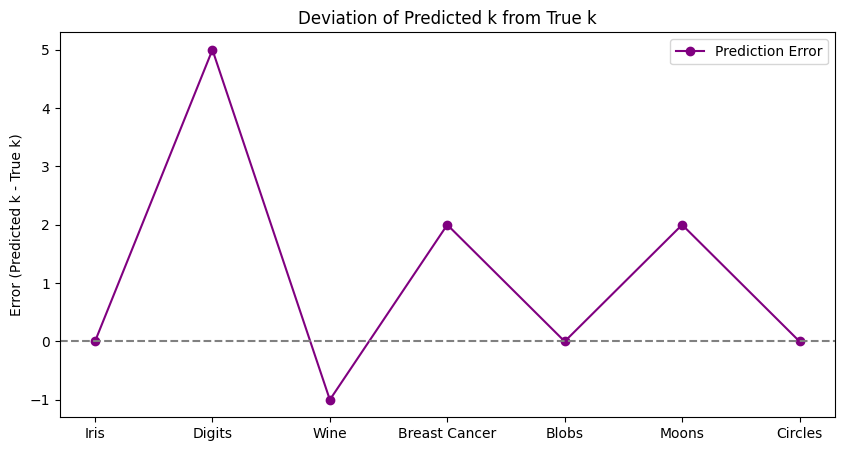

Dataset: Iris, True k: 3, Predicted k: 3, Similarity: 100%
Dataset: Digits, True k: 10, Predicted k: 15, Similarity: 50%
Dataset: Wine, True k: 3, Predicted k: 2, Similarity: 100%
Dataset: Breast Cancer, True k: 2, Predicted k: 4, Similarity: 80%
Dataset: Blobs, True k: 4, Predicted k: 4, Similarity: 100%
Dataset: Moons, True k: 2, Predicted k: 4, Similarity: 80%
Dataset: Circles, True k: 2, Predicted k: 2, Similarity: 100%

Average Similarity Across All Datasets: 87.14%


In [12]:
# Bar Chart for True k vs. Predicted k
plt.figure(figsize=(10, 5))
x = np.arange(len(dataset_names))
plt.bar(x - 0.2, true_k_values, width=0.4, label='True k', color='blue', alpha=0.7)
plt.bar(x + 0.2, predicted_k_values, width=0.4, label='Predicted k', color='red', alpha=0.7)
plt.xticks(x, dataset_names, rotation=45)
plt.ylabel("Number of Clusters (k)")
plt.title("Comparison of True k vs. Predicted k")
plt.legend()
plt.show()

# Line Plot for Prediction Error
plt.figure(figsize=(10, 5))
errors = np.array(predicted_k_values) - np.array(true_k_values)
plt.plot(dataset_names, errors, marker='o', linestyle='-', color='purple', label='Prediction Error')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Error (Predicted k - True k)")
plt.title("Deviation of Predicted k from True k")
plt.legend()
plt.show()


def calculate_similarity(true_k, predicted_k, threshold=1):
    """Calculate the similarity percentage based on how close true_k and predicted_k are."""
    # If the difference between true_k and predicted_k is within the threshold, count it as a close match
    if abs(true_k - predicted_k) <= threshold:
        return 100  # Perfect match
    else:
        # You can scale this percentage for larger differences (if desired)
        similarity = max(0, 100 - abs(true_k - predicted_k) * 10)  # 10% penalty per unit of difference
        return similarity

# Assuming you have the following lists from the previous loop:
# true_k_values, predicted_k_values, and dataset_names

similarities = []  # List to store the similarity percentages

# Calculate similarity for each dataset
for true_k, predicted_k, name in zip(true_k_values, predicted_k_values, dataset_names):
    similarity = calculate_similarity(true_k, predicted_k)  # Calculate similarity
    similarities.append((name, true_k, predicted_k, similarity))

    print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}, Similarity: {similarity}%")

# Optionally, calculate the average similarity across all datasets
average_similarity = np.mean([sim[3] for sim in similarities])
print(f"\nAverage Similarity Across All Datasets: {average_similarity:.2f}%")

    

### K means clustering representation:  

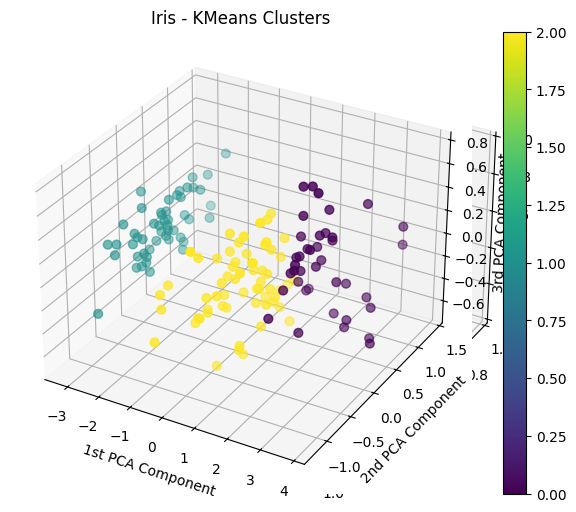

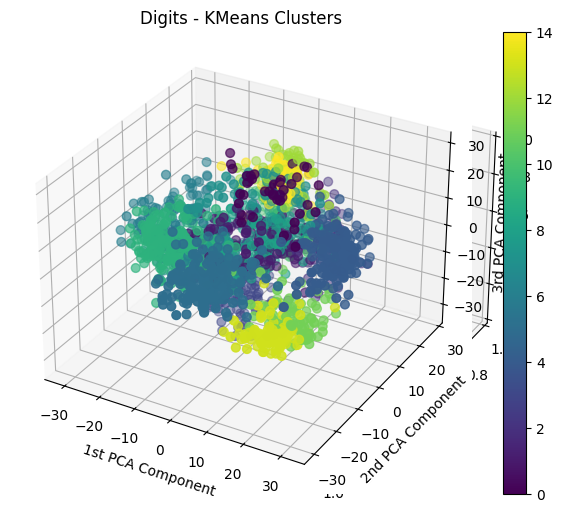

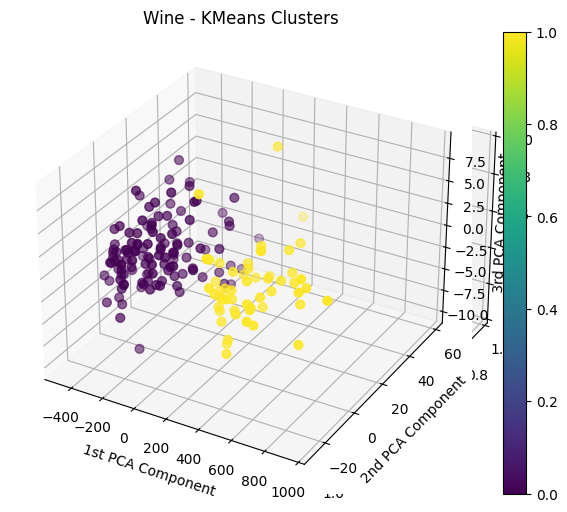

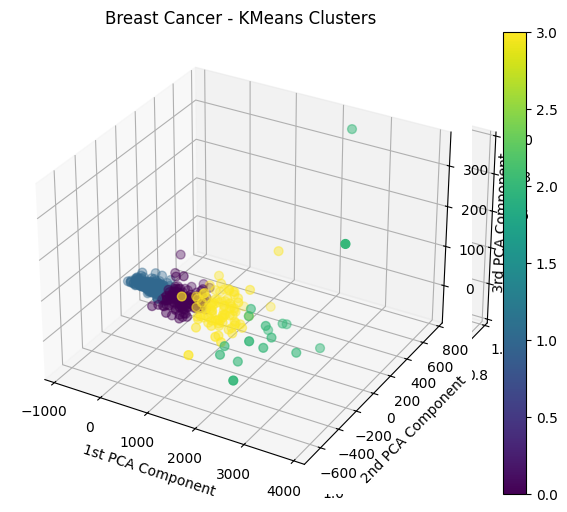

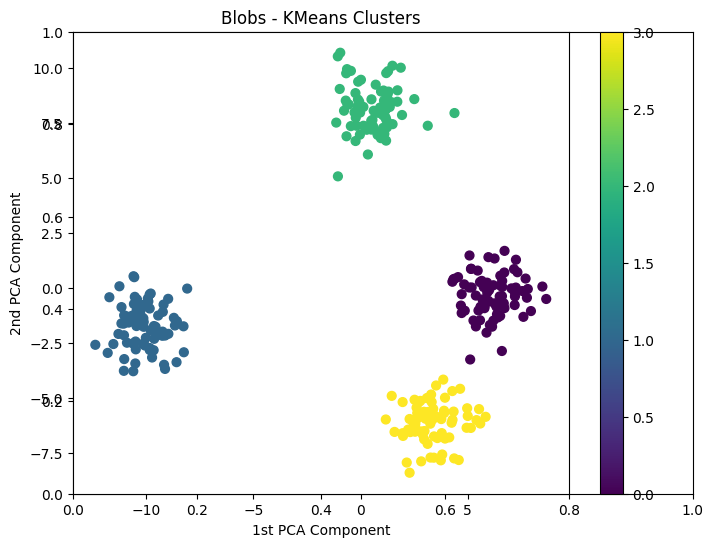

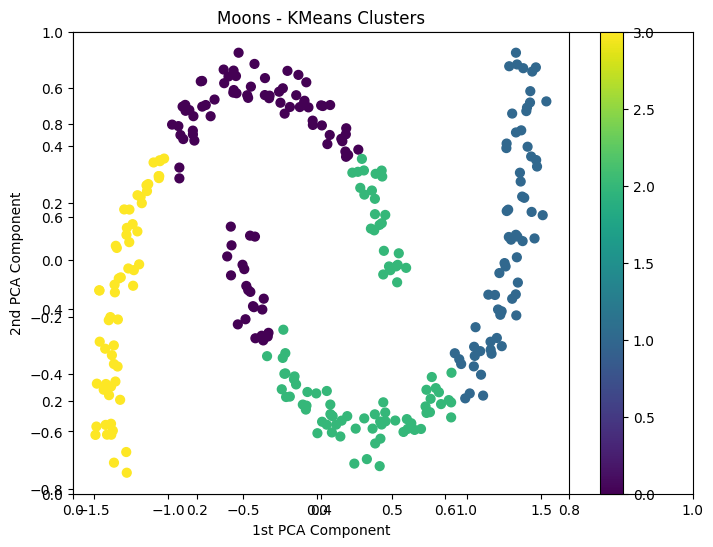

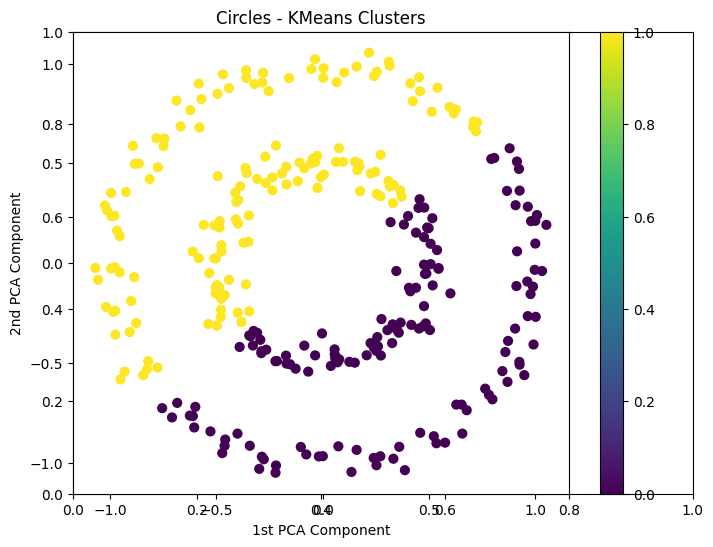

In [17]:

# Predefined datasets and their expected cluster counts
# datasets = {
#     "Iris": (load_iris().data, 3),
#     "Digits": (load_digits().data, 10),
#     "Wine": (load_wine().data, 3),
#     "Breast Cancer": (load_breast_cancer().data, 2),
#     "Blobs": (make_blobs(n_samples=300, centers=4, random_state=42)[0], 4),
#     "Moons": (make_moons(n_samples=300, noise=0.05, random_state=42)[0], 2),
#     "Circles": (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2),
# }

# Assuming predicted_k_values is already filled from your earlier code
# Example format of predicted_k_values: [3, 10, 3, 2, 4, 2, 2]

# Function to perform KMeans and plot the clusters
def plot_kmeans_clusters(X, k, title):
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    # Apply PCA to reduce to 3 dimensions for visualization, if possible
    n_features = X.shape[1]
    if n_features >= 3:
        pca = PCA(n_components=3)
    else:
        pca = PCA(n_components=2)

    X_reduced = pca.fit_transform(X)

    # Create the 3D or 2D plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d' if n_features >= 3 else 'rectilinear')

    if n_features >= 3:
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=y_kmeans, cmap='viridis', s=40)
        ax.set_zlabel("3rd PCA Component")
    else:
        ax = fig.add_subplot(111)  # No 'projection' argument for 2D
        scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_kmeans, cmap='viridis', s=40)

    ax.set_title(f"{title} - KMeans Clusters")
    ax.set_xlabel("1st PCA Component")
    ax.set_ylabel("2nd PCA Component")
    fig.colorbar(scatter)
    plt.show()



# Plot KMeans clusters for each dataset using the predicted k
for i, (name, (X, _)) in enumerate(datasets.items()):
    plot_kmeans_clusters(X, predicted_k_values[i], name)


### SOLUTION 2:
This code TRIES multiple K ON DIFFRENT scikit-learn datasets (breast cancer, iris, wine, digits) THEN calculating silhouette scores—a measure of clustering quality—for different numbers of clusters (k). It avoids repetition by using a single analysis function that loads each dataset, prints the true number of classes, then computes and displays how well K-Means clustering performs for various k values (2-7 for most datasets, 2-20 for digits). 
- BASED ON THE SILHOUETTE OF EACH K(WE TAKE THE K ASSOCIATED WITH THE BIGGEST SILHOTTE) WE COULD TELL WHAT IS THE MOST APPROPRIATE K TO TAKE.
- THIS SOLUTION SEEMS BETTER THAN THE PREVIOUS ONE.
- LIMITATION: Works decently on clean, preprocessed datasets like Iris, Often fails on real-world messy data with

In [19]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import anderson
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits, load_wine, load_breast_cancer, make_blobs, make_moons, make_circles
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import StandardScaler

def g_means(X, alpha=0.01, max_k=None, random_state=42):
    # Step 0: Preprocessing
    X = VarianceThreshold(threshold=0.1).fit_transform(X)  # Remove low-variance features
    n_components = max(2, min(10, int(0.9 * X.shape[1])))  # Keep 2-10 dimensions
    X_reduced = PCA(n_components=n_components).fit_transform(X)
    
    # Step 1: Initialize
    if max_k is None:
        max_k = min(15, int(0.1 * len(X)))  # Dynamic cap
    centers = [np.mean(X_reduced, axis=0)]
    
    prev_dbi = None  # Track Davies-Bouldin Index
    
    # Step 2: Iterative splitting
    while len(centers) < max_k:
        kmeans = KMeans(n_clusters=len(centers), init=np.array(centers), n_init=1, random_state=random_state)
        labels = kmeans.fit_predict(X_reduced)
        centers = kmeans.cluster_centers_
        
        # Compute Davies-Bouldin Index only if k > 1
        if len(centers) > 1:
            current_dbi = davies_bouldin_score(X_reduced, labels)
            
            # If the Davies-Bouldin Index increases, stop splitting
            if prev_dbi is not None and current_dbi > prev_dbi:
                break  # Stop splitting if clusters are getting worse
            prev_dbi = current_dbi  # Update best DBI score
        
        new_centers = []
        changed = False
        
        for j in range(len(centers)):
            cluster_data = X_reduced[labels == j]
            min_cluster_size = max(10, int(0.02 * len(X)))
            
            if len(cluster_data) < min_cluster_size:
                new_centers.append(centers[j])
                continue
                
            # Projection and Gaussian test
            centered = cluster_data - centers[j]
            cov = np.cov(centered.T)
            eigvals, eigvecs = np.linalg.eigh(cov)
            direction = eigvecs[:, np.argmax(eigvals)]
            projected = np.dot(centered, direction)
            
            standardized = (projected - np.mean(projected)) / np.std(projected)
            ad_stat = anderson(standardized).statistic
            critical = anderson(standardized).critical_values[2] * (1 + np.log(len(cluster_data)) / 10)
            
            if ad_stat > critical:
                offset = 0.3 * np.std(projected) * direction  # Smaller split
                new_centers.extend([centers[j] + offset, centers[j] - offset])
                changed = True
            else:
                new_centers.append(centers[j])
        
        if not changed:
            break
        centers = new_centers
    
    # Final result
    return len(centers)


# Predefined datasets and their expected cluster counts
datasets = {
    "Iris": (load_iris().data, 3),
    "Digits": (load_digits().data, 10),
    "Wine": (load_wine().data, 3),
    "Breast Cancer": (load_breast_cancer().data, 2),
    "Blobs": (make_blobs(n_samples=300, centers=4, random_state=42)[0], 4),
    "Moons": (make_moons(n_samples=300, noise=0.05, random_state=42)[0], 2),
    "Circles": (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2),
}

# Run G-Means on each dataset
for name, (X, true_k) in datasets.items():
    predicted_k = g_means(X, alpha=0.05)
    print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}")


Dataset: Iris, True k: 3, Predicted k: 3
Dataset: Digits, True k: 10, Predicted k: 15
Dataset: Wine, True k: 3, Predicted k: 2
Dataset: Breast Cancer, True k: 2, Predicted k: 4
Dataset: Blobs, True k: 4, Predicted k: 4
Dataset: Moons, True k: 2, Predicted k: 4
Dataset: Circles, True k: 2, Predicted k: 2
